In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
df = pd.read_csv(r'C:\Users\GOKKUL\OneDrive\Desktop\ML_Shaastra\IOH_data_coord_app.csv')
print(df.head())


   userId registerType         category       state         city  groupSize  \
0    1802        GROUP           FAMILY  Tamil Nadu       Guntur          4   
1    1191   INDIVIDUAL  COLLEGE_STUDENT  Tamil Nadu  Thiruvallur          1   
2    1818        GROUP           FAMILY  Tamil Nadu  Thiruvallur          4   
3     252   INDIVIDUAL  COLLEGE_STUDENT  Tamil Nadu  Kanchipuram          1   
4    2506   INDIVIDUAL  COLLEGE_STUDENT      Kerala     Tirupati          1   

                        collegeName companyName  isPresent  
0                               NaN         NaN          0  
1  Chennai institute of technology          NaN          0  
2                               NaN         NaN          1  
3  Velammal institute of technology         NaN          0  
4  Chennai institute of technology          NaN          0  


In [3]:
df.value_counts('category')

category
COLLEGE_STUDENT          1228
FAMILY                   1070
OTHERS                    508
INDUSTRY_PROFESSIONAL     132
INSTITUTE                  62
Name: count, dtype: int64

In [4]:
df.value_counts(['category','isPresent'])

category               isPresent
COLLEGE_STUDENT        0            759
FAMILY                 0            614
COLLEGE_STUDENT        1            469
FAMILY                 1            456
OTHERS                 0            354
                       1            154
INDUSTRY_PROFESSIONAL  0             81
                       1             51
INSTITUTE              1             45
                       0             17
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   userId        3000 non-null   int64 
 1   registerType  3000 non-null   object
 2   category      3000 non-null   object
 3   state         3000 non-null   object
 4   city          3000 non-null   object
 5   groupSize     3000 non-null   int64 
 6   collegeName   1228 non-null   object
 7   companyName   132 non-null    object
 8   isPresent     3000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 211.1+ KB


In [6]:
df['isPresent'].value_counts()

isPresent
0    1825
1    1175
Name: count, dtype: int64

In [7]:
df['groupSize'].value_counts()

groupSize
1      1868
3       231
2       219
6       211
4       208
5       201
32        3
108       3
75        3
91        2
114       2
27        2
51        2
89        2
53        2
101       2
62        2
100       2
95        2
70        2
72        2
19        2
115       2
71        1
21        1
81        1
43        1
60        1
84        1
46        1
45        1
86        1
102       1
17        1
57        1
20        1
55        1
78        1
47        1
88        1
83        1
52        1
68        1
94        1
117       1
93        1
64        1
103       1
Name: count, dtype: int64

In [8]:
df['city'].value_counts()

city
Kakinada         209
Chennai          206
Coimbatore       204
Kanchipuram      202
Vellore          202
Tirupati         196
Nellore          190
Vijayawada       190
Other            188
Tiruvallur       182
Guntur           179
Bangalore        175
Visakhapatnam    173
Thiruvallur      171
Chengalpattu     170
Hyderabad        163
Name: count, dtype: int64

In [9]:
df['state'].value_counts()

state
Tamil Nadu        1968
Andhra Pradesh     435
Telangana          232
Karnataka          159
Kerala              88
Puducherry          61
Other               57
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import OneHotEncoder
X = df[['category','city','state','groupSize']]
y = df[['isPresent']]
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = ohe.fit_transform(X[['category']])

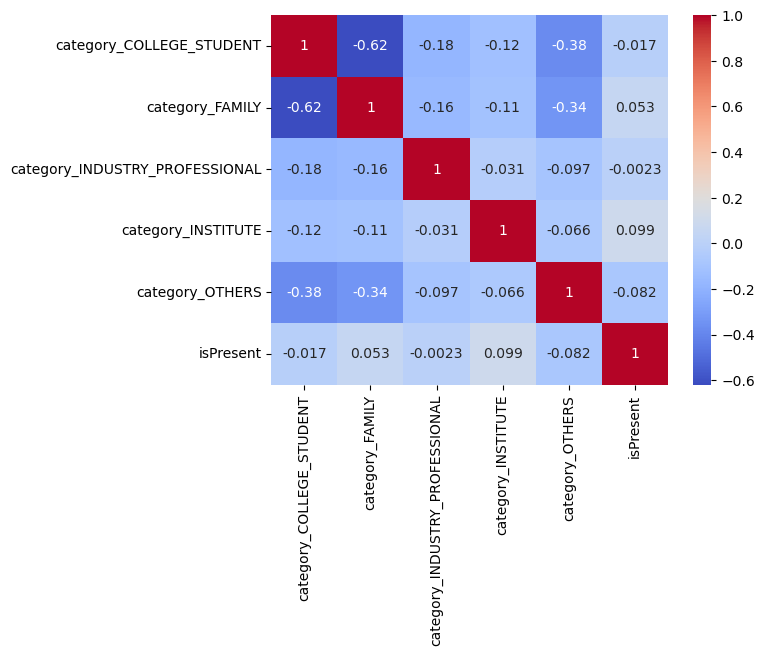

In [11]:
df1 = pd.DataFrame(X_encoded, columns=ohe.get_feature_names_out(['category']))
df_final = pd.concat([df1, df.drop(columns=['category','userId','groupSize']).reset_index(drop=True)], axis=1)
sns.heatmap(df_final[df_final.select_dtypes(include=[np.number]).columns].corr(), annot=True, cmap='coolwarm')
plt.show()

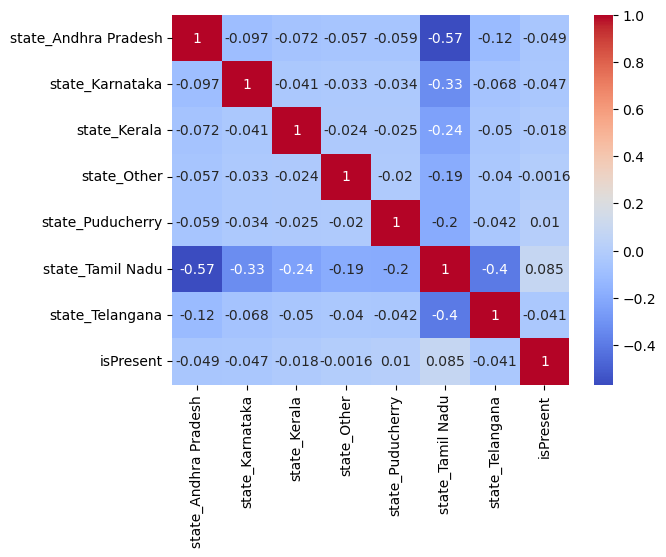

In [12]:
X_encoded2 = ohe.fit_transform(X[['state']])
df2 = pd.DataFrame(X_encoded2, columns=ohe.get_feature_names_out(['state']))
df_final2 = pd.concat([df2, df.drop(columns=['userId','state','groupSize']).reset_index(drop=True)], axis=1)
sns.heatmap(df_final2[df_final2.select_dtypes(include=[np.number]).columns].corr(), annot=True, cmap='coolwarm')
plt.show()

In [13]:
df_final2

,state_Andhra Pradesh,state_Karnataka,state_Kerala,state_Other,state_Puducherry,state_Tamil Nadu,state_Telangana,registerType,category,city,collegeName,companyName,isPresent
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,GROUP,FAMILY,Guntur,NaN,NaN,0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,INDIVIDUAL,COLLEGE_STUDENT,Thiruvallur,Chennai institute of technology,NaN,0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,GROUP,FAMILY,Thiruvallur,NaN,NaN,1
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,INDIVIDUAL,COLLEGE_STUDENT,Kanchipuram,Velammal institute of technology,NaN,0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,INDIVIDUAL,COLLEGE_STUDENT,Tirupati,Chennai institute of technology,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.0,0.0,0.0,0.0,0.0,1.0,0.0,INDIVIDUAL,OTHERS,Guntur,NaN,NaN,0
2996,1.0,0.0,0.0,0.0,0.0,0.0,0.0,INDIVIDUAL,COLLEGE_STUDENT,Kakinada,Velammal institute of technology,NaN,0
2997,0.0,0.0,0.0,0.0,0.0,1.0,0.0,GROUP,FAMILY,Coimbatore,NaN,NaN,1
2998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,INDIVIDUAL,INDUSTRY_PROFESSIONAL,Vellore,NaN,SETS,1


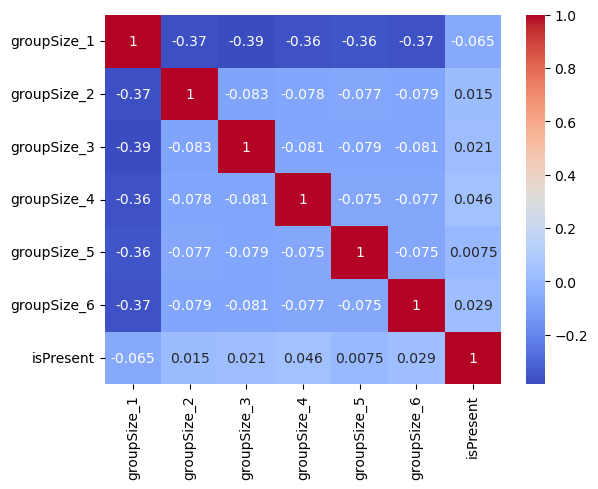

In [14]:
# Step 1: filter rows
df_subset = df[df['groupSize'].isin([1, 2, 3, 4, 5,6])]

# Step 2: apply OneHotEncoder on ONLY the column
X_encoded4 = ohe.fit_transform(df_subset[['groupSize']])

# Step 3: convert to DataFrame
df4 = pd.DataFrame(
    X_encoded4,
    columns=ohe.get_feature_names_out(['groupSize'])
)

# Step 4: combine with rest of data
df_final4 = pd.concat(
    [df4, df_subset.drop(columns=['userId', 'groupSize']).reset_index(drop=True)],
    axis=1
)

# Step 5: heatmap
sns.heatmap(
    df_final4.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [15]:
def top_attendance_table(df, column, min_count=1):
    table = (
        df.groupby(column)
        .agg(registrations=("isPresent", "size"), attendance_rate=("isPresent", "mean"))
        .reset_index()
    )
    table["attendance_rate"] = (table["attendance_rate"] * 100).round(2)
    return table[table["registrations"] >= min_count].sort_values(
        "attendance_rate", ascending=False
    )
print(top_attendance_table(df, 'category'))
print(top_attendance_table(df, 'state'))
print(top_attendance_table(df, 'groupSize',min_count=10))
print(top_attendance_table(df, 'city'))

                category  registrations  attendance_rate
3              INSTITUTE             62            72.58
1                 FAMILY           1070            42.62
2  INDUSTRY_PROFESSIONAL            132            38.64
0        COLLEGE_STUDENT           1228            38.19
4                 OTHERS            508            30.31
            state  registrations  attendance_rate
4      Puducherry             61            42.62
5      Tamil Nadu           1968            42.17
3           Other             57            38.60
2          Kerala             88            34.09
0  Andhra Pradesh            435            33.33
6       Telangana            232            32.33
1       Karnataka            159            29.56
   groupSize  registrations  attendance_rate
3          4            208            46.63
5          6            211            43.60
2          3            231            41.99
1          2            219            41.10
4          5            201      

In [16]:
df["collegeName_clean"] = (
    df["collegeName"]
    .str.strip()
    .str.lower()
    .str.title()
)



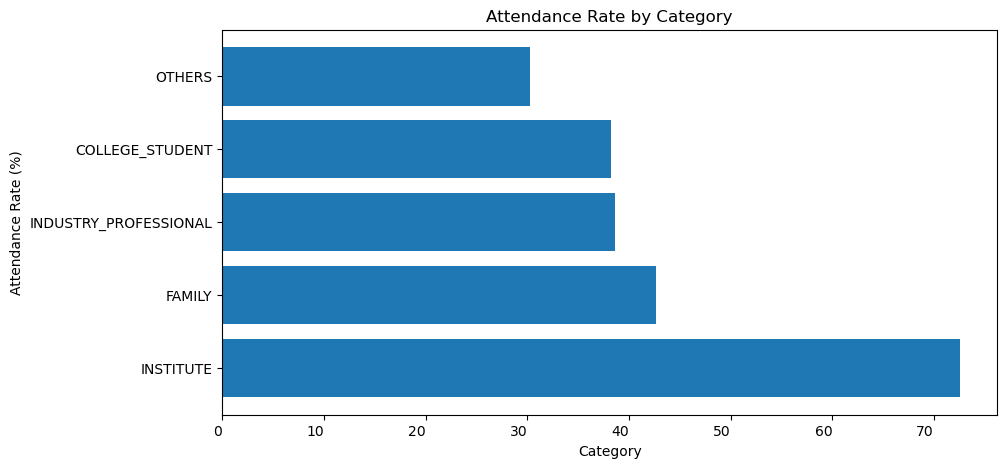

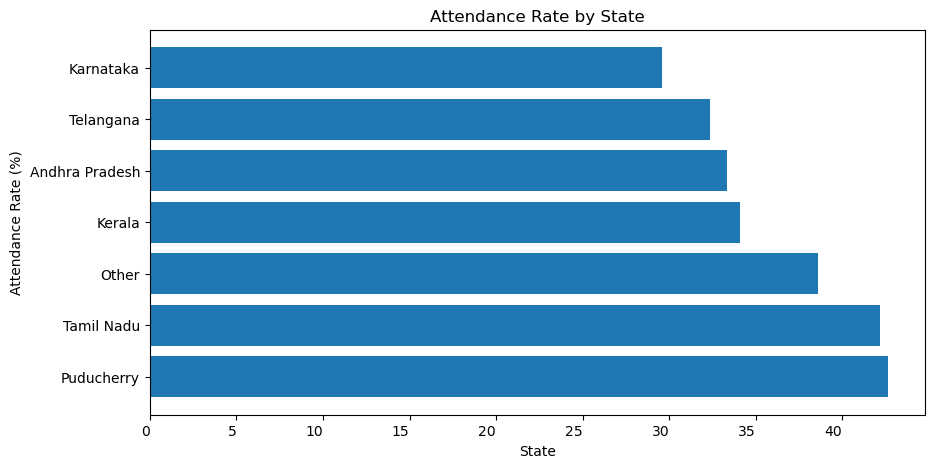

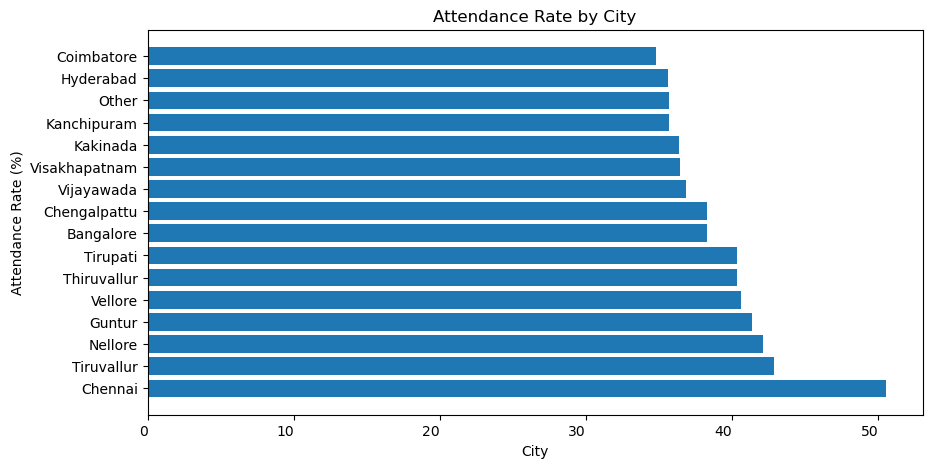

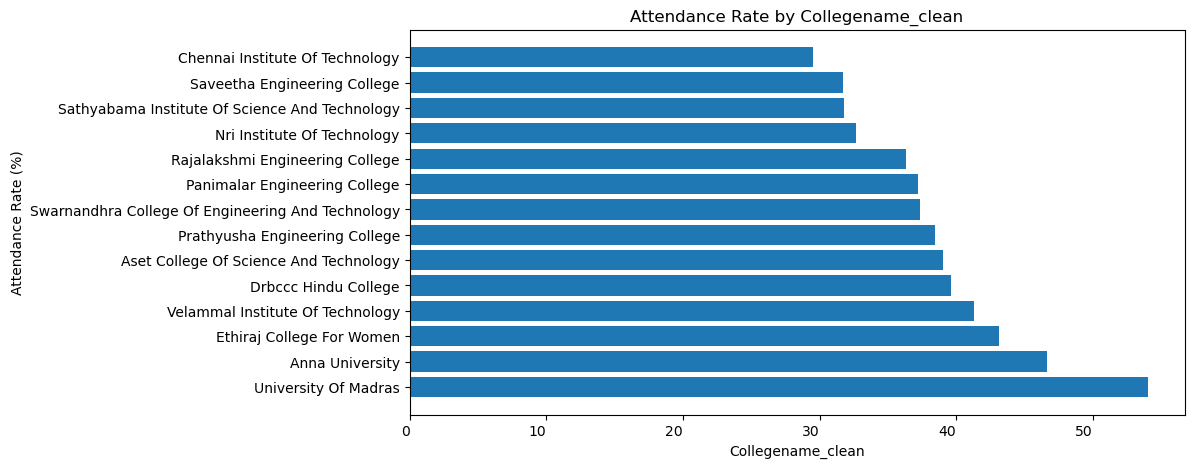

In [17]:
for i in ['category', 'state','city','collegeName_clean']:
    category_table = top_attendance_table(df, i,min_count=10)

    plt.figure(figsize=(10, 5))
    plt.barh(category_table[i], category_table["attendance_rate"])


    
    plt.title(f"Attendance Rate by {i.capitalize()}")
    plt.xlabel(i.capitalize())
    plt.ylabel("Attendance Rate (%)")
    plt.xticks(rotation=0, ha="right")

    plt.show()




In [18]:
def make_preprocessor(X) :
    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe),
        ]
    )
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_pipe, categorical_cols),
            ("numeric", numeric_pipe, numeric_cols),
        ]
    )

In [27]:
def clean_and_create_features(X):
        X = X.copy()
        text_cols = [
            "registerType",
            "category",
            "state",
            "city",
            "collegeName",
            "companyName",
        ]
        for col in text_cols:
            X[col] = (
                X[col]
                .fillna("missing")
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"": "missing", "nan": "missing", "none": "missing"})
            )

        X["has_college"] = (X["collegeName"] != "missing").astype(int)
        X["has_company"] = (X["companyName"] != "missing").astype(int)
        X["is_group_registration"] = (X["registerType"] == "group").astype(int)
        X["is_individual_registration"] = (X["registerType"] == "individual").astype(int)
        X["is_solo_registration"] = (X["groupSize"] == 1).astype(int)
        X["is_large_group"] = (X["groupSize"] >= 4).astype(int)
        X["groupSize_clipped"] = X["groupSize"].clip(lower=1, upper=8)
        X["log_groupSize"] = np.log1p(X["groupSize"])

        X["category_registerType"] = X["category"] + "__" + X["registerType"]
        X["category_groupSize"] = X["category"] + "__" + X["groupSize_clipped"].astype(str)
        X["state_city"] = X["state"] + "__" + X["city"]
        X["state_category"] = X["state"] + "__" + X["category"]
        X["city_category"] = X["city"] + "__" + X["category"]
        X["org_name"] = np.where(X["collegeName"] != "missing", X["collegeName"], X["companyName"])
        X["org_category"] = X["org_name"] + "__" + X["category"]

        X = X.drop(columns=["isPresent"], errors="ignore")
        X = X.drop(columns=["userId"], errors="ignore")
        return X

In [28]:
def get_feature_names(model: Pipeline, X: pd.DataFrame) -> list[str]:
    preprocessor = model.named_steps["preprocessor"]
    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
    cat_encoder = preprocessor.named_transformers_["categorical"].named_steps["onehot"]
    cat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
    return cat_names + numeric_cols

In [29]:
df.columns.tolist()

['userId',
 'registerType',
 'category',
 'state',
 'city',
 'groupSize',
 'collegeName',
 'companyName',
 'isPresent',
 'collegeName_clean']

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

X = clean_and_create_features(df)
y = df["isPresent"]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

preprocessor = make_preprocessor(X)
models = {
        "Logistic Regression": {
           "model" : LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=42),
           "param_grid": {
                "model__C": [0.01, 0.1, 1, 10, 100],
                "model__penalty": ["l1", "l2"],
                "model__solver": ["liblinear"],
            }}
        ,
        "Random Forest": {
            "model": RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
        ),
         "param_grid": {
                "model__n_estimators": [100, 200, 300],
                "model__max_depth": [4, 6, 8, 10, None],
                "model__min_samples_leaf": [2, 5, 8, 10,16],
                "model__max_features": ["sqrt", "log2"]
            }},
       "Gradient Boosting": {
            "model": GradientBoostingClassifier(
                random_state=42
            ),
             "param_grid": {
                "model__n_estimators": [100, 200, 300],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__max_depth": [3, 5, 7],
            }
       },
     "XGBoost": {
            "model": XGBClassifier(
            scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
            random_state=42,
        ),
        "param_grid": {
                "model__n_estimators": [100, 200, 300],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__max_depth": [3, 5, 7],
            }},
    "KNN": {
            "model": KNeighborsClassifier(),
            "param_grid": {
                "model__n_neighbors": [3, 5, 7, 9],
                "model__weights": ["uniform", "distance"],
                "model__metric": ["euclidean", "manhattan"],
            }},
     "Decision Tree": {
            "model": DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42,
            ),
            "param_grid": { 
                "model__max_depth": [4, 6, 8, 10, None],
                "model__min_samples_leaf": [2, 5, 8, 10,16],
                "model__max_features": ["sqrt", "log2"]
            }},
     "SVM": {
            "model": SVC(
                class_weight="balanced",
                probability=True,
                random_state=42,
            ),
            "param_grid": {
                "model__C": [0.1, 1, 10],
                "model__kernel": ["linear", "rbf"],
            }},       
    "Extra_Trees": {
            "model": ExtraTreesClassifier(
                class_weight="balanced",
                random_state=42,
            ),
             "param_grid": {
                "model__n_estimators": [100, 200, 300],
                "model__max_depth": [4, 6, 8, 10,   None],
                "model__min_samples_leaf": [2, 5, 8, 10,16],
                "model__max_features": ["sqrt", "log2"]},
    "Balanced RF": {
        "model": BalancedRandomForestClassifier(
        random_state=42
    ),
        "param_grid": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 5, 10],
    }
}           
    }}

results = []
fitted_models = {}
for name, estimator in models.items():
        pipeline = Pipeline(
            steps=[("preprocessor", preprocessor), ("model", estimator['model'])]
        )
        grid_search = GridSearchCV(
            pipeline, param_grid=estimator["param_grid"], cv=5, n_jobs=-1, scoring="roc_auc"
        )
        grid_search.fit(X_train, y_train)
        y_pred = grid_search.predict(X_test)
        y_proba = grid_search.predict_proba(X_test)[:, 1]
        results.append(
            {
                "model": name,
                "accuracy": accuracy_score(y_test, y_pred),
                "precision": precision_score(y_test, y_pred),
                "recall": recall_score(y_test, y_pred),
                "f1": f1_score(y_test, y_pred),
                "roc_auc": roc_auc_score(y_test, y_proba),
            }
        )
        fitted_models[name] = grid_search.best_estimator_

metrics_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
best_model_name = metrics_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]


print(classification_report(y_test, best_pred))
metrics_df


              precision    recall  f1-score   support

           0       0.64      0.68      0.66       365
           1       0.45      0.40      0.42       235

    accuracy                           0.57       600
   macro avg       0.54      0.54      0.54       600
weighted avg       0.56      0.57      0.57       600



,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.570000,0.446009,0.404255,0.424107,0.576922
0,Logistic Regression,0.585000,0.463542,0.378723,0.416862,0.575611
7,Extra_Trees,0.578333,0.459459,0.434043,0.446389,0.574311
3,XGBoost,0.588333,0.467391,0.365957,0.410501,0.566639
2,Gradient Boosting,0.620000,0.733333,0.046809,0.088000,0.561067
5,Decision Tree,0.566667,0.445887,0.438298,0.442060,0.545683
6,SVM,0.546667,0.425703,0.451064,0.438017,0.540035
4,KNN,0.543333,0.393443,0.306383,0.344498,0.505171


In [31]:
feature_names = get_feature_names(best_model, X_train)
estimator = best_model.named_steps["model"]
if hasattr(estimator, "feature_importances_"):
        importances = estimator.feature_importances_
        importance_title = "Most Useful Prediction Clues"
else:
        importances = np.abs(estimator.coef_[0])
        importance_title = "Strongest Prediction Signals"
importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )

In [32]:
importance_df

,feature,importance
230,state_category_tamil nadu__family,0.060874
402,log_groupSize,0.053256
12,state_tamil nadu,0.045425
401,groupSize_clipped,0.042663
394,groupSize,0.036477
95,category_groupSize_others__1,0.035103
94,category_groupSize_institute__8,0.034296
5,category_institute,0.033643
86,category_registerType_others__individual,0.032623
373,org_category_missing__others,0.031106


In [33]:
print("Confusion matrix is for:", best_model_name)


Confusion matrix is for: Random Forest


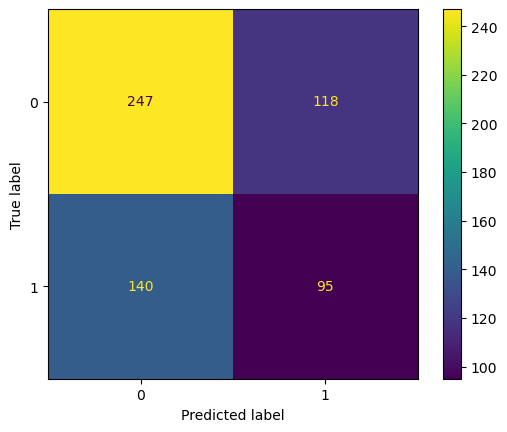

In [34]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()